# MAPLES-DR Dataset — Exploratory Data Analysis
**Objective:** Analyze the completeness, distribution, and quality of the dataset.  
**Dataset:** MESSIDOR images + MAPLES-DR segmentation masks  
**Target Classes:** OpticDisc, Macula, Exudates, Hemorrhages, Microaneurysms, Drusens

---
## Notebook Structure
| Step | Topic |
|------|-------|
| 1 | Dataset Inventory |
| 2 | True Lesion Presence (Non-Empty Masks) |
| 3 | Pixel-Level Area Statistics |
| 4 | Spatial Heatmaps |
| 5 | Filtered Stats for Target Classes |
| 6 | Visual Audit (Overlay) |
| 7 | Image Resolution & Aspect Ratio |
| 8 | Lesion Area Percentage (Log Scale) |
| 9 | Multi-label Co-occurrence Matrix |
| 10 | Color Intensity Distribution |

## 0. Configuration & Imports

In [43]:
import os
import glob

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from PIL import Image



- Plot Theme confg

In [2]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

- Dataset Path

In [ ]:
base_dir = Path.cwd()/'MAPLES_Matched'
col_images = os.path.join(base_dir,'images')
col_masks  = os.path.join(base_dir, 'masks')

- Output Path

In [130]:
save_dir = Path.cwd()/'EDA_Results'
img_result = save_dir/'fig'
csv_result = save_dir/'statistic'

- Target Classes for Analysis

In [4]:
target_class = ["OpticDisc", "Macula", "Exudates", "Hemorrhages", "Drusens"]
class_colors = {
    "OpticDisc":   (  0, 255, 255),  
    "Macula":      (255,   0,   0),   
    "Exudates":    (255, 255,   0),   
    "Hemorrhages": (  0, 255,   0),   
    "Drusens":     (255, 0, 255), 
}

---
## Step 1 — Dataset Inventory
Check if, after including the files in `MAPLES_Matched`, all classes have the correct files.

1. Inventory scan

In [5]:
total_img = len([
    f for f in os.listdir(col_images)
        if f.lower().endswith((".png",".tif",".png"))
])
available_classes = sorted([
    d for d in os.listdir(col_masks) 
        if os.path.join(col_masks, d)
])

In [6]:
inventory = [
    {
        "Class" : cls,
        'File_count': len(os.listdir(os.path.join(col_masks, cls)))
    }
    for cls in available_classes
]
df_invent = pd.DataFrame(inventory)

In [7]:
print(f'Total Unique Images: {total_img}')
print(f'Total Classes Found: {len(available_classes)}')
display(df_invent)

Total Unique Images: 198
Total Classes Found: 12


,Class,File_count
0,BrightUncertains,198
1,CottonWoolSpots,198
2,Drusens,198
3,Exudates,198
4,Hemorrhages,198
5,Macula,197
6,Microaneurysms,198
7,Neovascularization,198
8,OpticCup,192
9,OpticDisc,198


- Export Statistic

In [133]:
invent_path = os.path.join(csv_result,'All_Class_Count.csv')
df_invent.to_csv(invent_path, index= False)
print(f'Saved result to: {invent_path}')

Saved result to: d:\Backup\Senior-Project\Pre-Train\EDA_Results\statistic\All_Class_Count.csv


---
## Step 2 — True Lesion Presence (Non-Empty Masks)

In [8]:
presence_stats=[]
for cls in tqdm(available_classes, desc="Scanning Masks"):
    cls_path   = os.path.join(col_masks, cls)
    mask_files = os.listdir(cls_path)
    n_present  = sum(
        np.any(np.array(Image.open(os.path.join(cls_path, f)).convert("L")) > 0)
        for f in mask_files
    )
    presence_stats.append({
        "Class":           cls,
        "Total_Files":     len(mask_files),
        "Actual_Present":  n_present,
        "Presence_Rate_%": round(n_present / len(mask_files) * 100, 1),
    })

df_presence = pd.DataFrame(presence_stats).sort_values("Actual_Present", ascending=False)
display(df_presence)

Scanning Masks: 100%|██████████| 12/12 [00:20<00:00,  1.74s/it]


,Class,Total_Files,Actual_Present,Presence_Rate_%
9,OpticDisc,198,198,100.0
11,Vessels,198,198,100.0
5,Macula,197,197,100.0
8,OpticCup,192,192,100.0
6,Microaneurysms,198,191,96.5
4,Hemorrhages,198,122,61.6
3,Exudates,198,104,52.5
2,Drusens,198,90,45.5
0,BrightUncertains,198,68,34.3
1,CottonWoolSpots,198,61,30.8


- Export Statistic

In [134]:
presence_path = os.path.join(csv_result,'Class_Presence_Rate.csv')
df_presence.to_csv(presence_path, index= False)
print(f'Saved result to: {presence_path}')

Saved result to: d:\Backup\Senior-Project\Pre-Train\EDA_Results\statistic\Class_Presence_Rate.csv


---
## Step 3 — Pixel-Level Area Statistics
Calculate avg / max / min pixel area **Only Lesion Mask**

In [9]:
pixel_stats = []

for cls in tqdm(available_classes, desc="Pixel Area"):
    cls_path = os.path.join(col_masks, cls)
    areas    = [
        int(np.sum(np.array(Image.open(os.path.join(cls_path, f)).convert("L")) > 0))
        for f in os.listdir(cls_path) if f.endswith(".png")
    ]
    areas = [a for a in areas if a > 0]   # keep non-empty only
    if areas:
        pixel_stats.append({
            "Class":            cls,
            "N_Positive":       len(areas),
            "Avg_Pixel_Area":   round(float(np.mean(areas)), 1),
            "Median_Pixel_Area":int(np.median(areas)),
            "Max_Pixel_Area":   int(np.max(areas)),
            "Min_Pixel_Area":   int(np.min(areas)),
        })
df_pixel = pd.DataFrame(pixel_stats).sort_values("Avg_Pixel_Area", ascending=False)
display(df_pixel)

Pixel Area: 100%|██████████| 12/12 [00:25<00:00,  2.12s/it]


,Class,N_Positive,Avg_Pixel_Area,Median_Pixel_Area,Max_Pixel_Area,Min_Pixel_Area
11,Vessels,198,167839.4,126427,352885,40934
7,Neovascularization,6,40782.2,14423,116544,90
9,OpticDisc,198,22994.3,18592,52214,6447
3,Exudates,104,8633.9,1964,88457,38
4,Hemorrhages,122,5536.6,1383,111503,55
8,OpticCup,192,4222.2,3624,18107,192
1,CottonWoolSpots,61,3361.2,1335,23988,151
6,Microaneurysms,191,3275.7,1555,28386,33
0,BrightUncertains,68,2156.9,402,67228,35
2,Drusens,90,1941.7,502,23307,33


C:\Users\natth\AppData\Local\Temp\ipykernel_39652\2675524996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pixel, x="Class", y="Avg_Pixel_Area", ax=ax, palette="coolwarm")


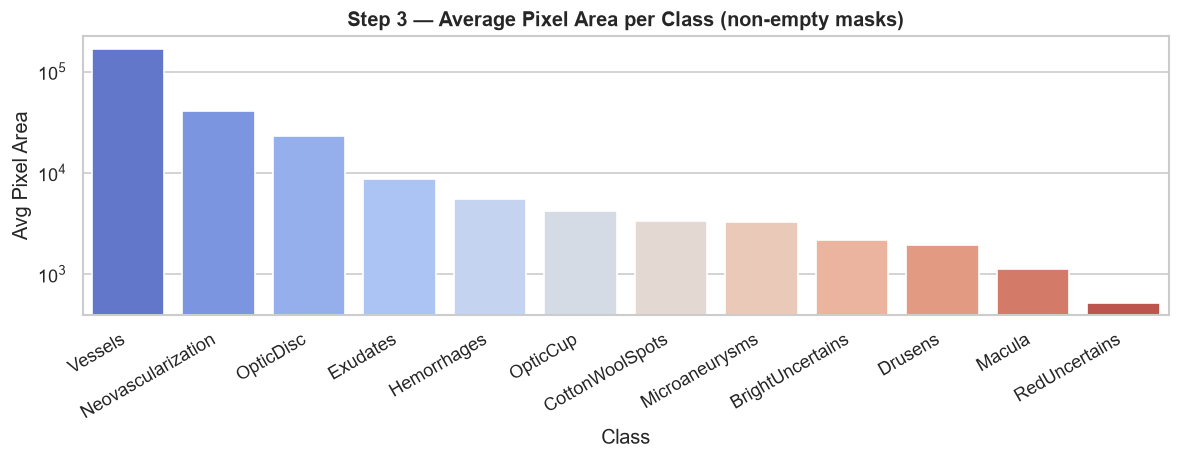

In [137]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=df_pixel, x="Class", y="Avg_Pixel_Area", ax=ax, palette="coolwarm")
ax.set_title("Step 3 — Average Pixel Area per Class (non-empty masks)", fontweight="bold")
ax.set_xlabel("Class"); ax.set_ylabel("Avg Pixel Area")
ax.set_yscale("log")   # log scale — areas differ by orders of magnitude
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); 
# Export Graph to Image
fig_path = os.path.join(img_result, 'Avg_Pixel_Area.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

- Export output (CSV)

In [135]:
pixel_path = os.path.join(csv_result,'Class_Pixel.csv')
df_pixel.to_csv(pixel_path, index= False)
print(f'Saved result to: {pixel_path}')

Saved result to: d:\Backup\Senior-Project\Pre-Train\EDA_Results\statistic\Class_Pixel.csv


---
## Step 4 — Spatial Heatmaps

- Heatmap configuration

In [11]:
HEATMAP_SIZE = (512, 512)

- Initialization

In [12]:
heatmaps = {cls: np.zeros(HEATMAP_SIZE, dtype=np.float32) for cls in available_classes}

In [13]:
for cls in tqdm(available_classes, desc="Spatial Heatmaps"):
    cls_path = os.path.join(col_masks, cls)
    for fname in os.listdir(cls_path):
        mask = Image.open(os.path.join(cls_path, fname))\
                    .convert("L")\
                    .resize(HEATMAP_SIZE, Image.NEAREST)
        
        heatmaps[cls] += (np.array(mask) > 0)

Spatial Heatmaps: 100%|██████████| 12/12 [00:14<00:00,  1.18s/it]


- Plot the Heatmap

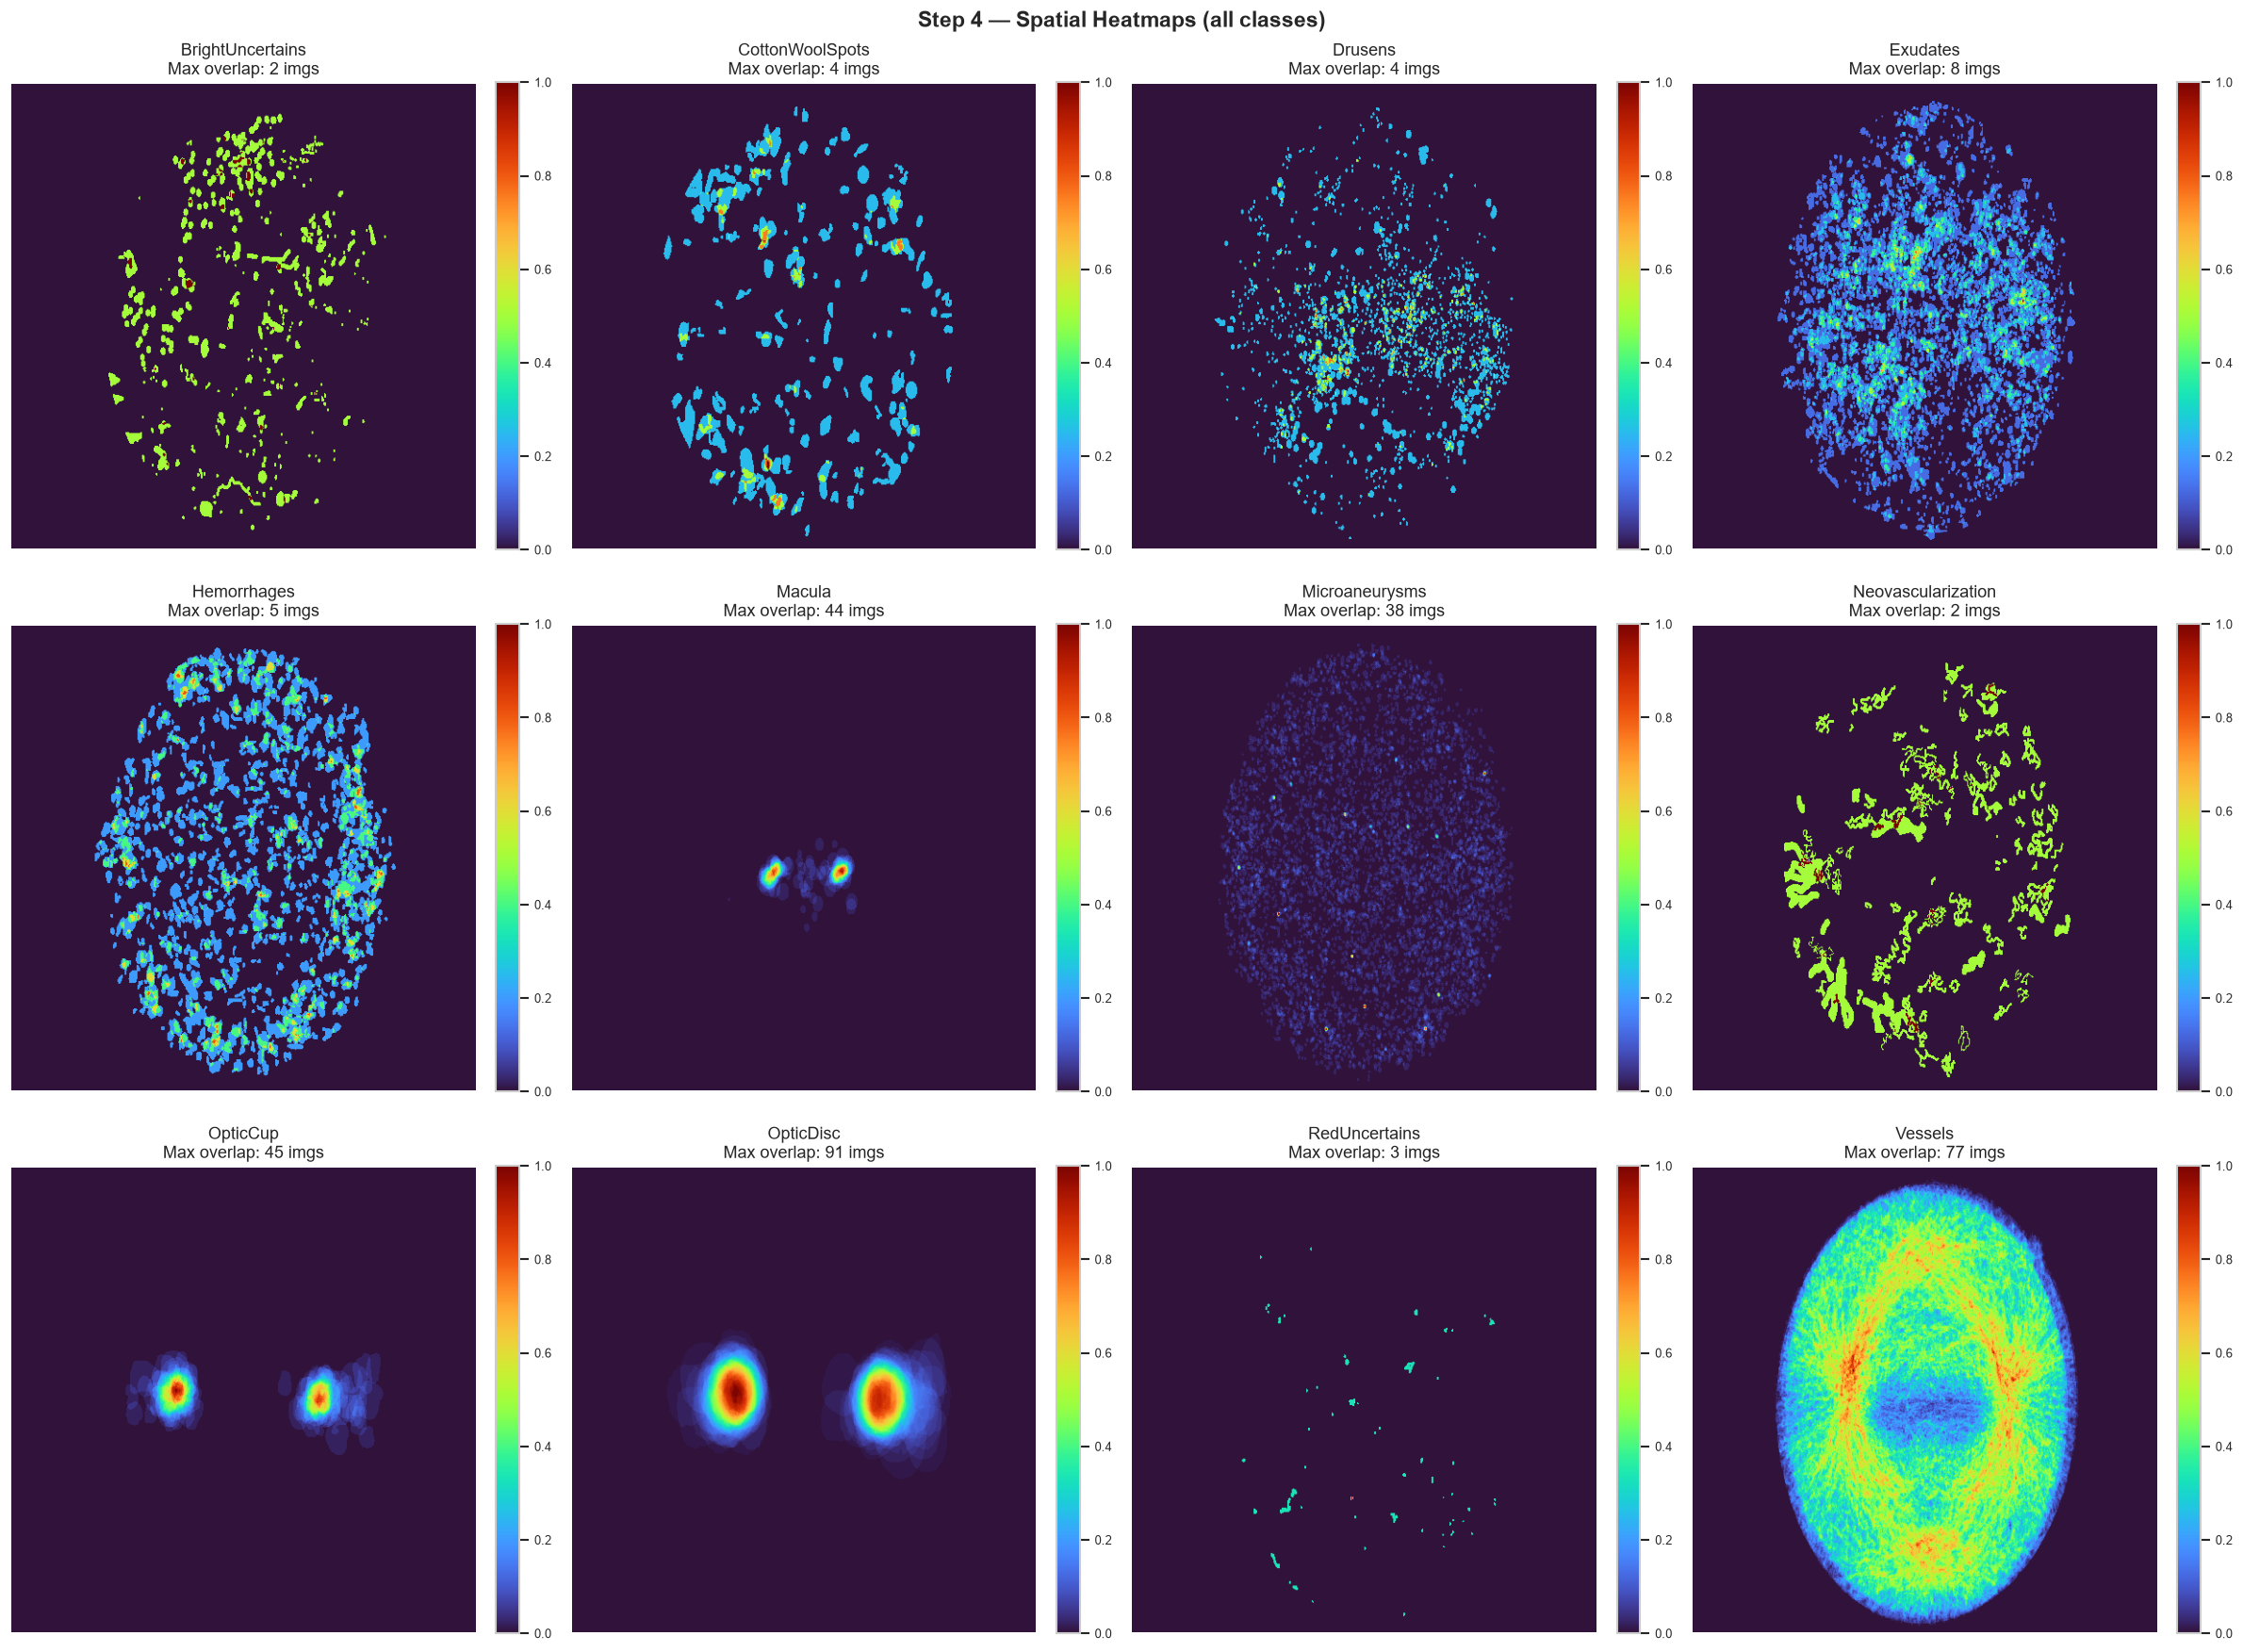

In [138]:
COLS = 4
ROWS = -(-len(available_classes) // COLS)
fig, axes = plt.subplots(ROWS, COLS, figsize=(20, 5 * ROWS))
axes = axes.flatten()

for i, cls in enumerate(available_classes):
    ax = axes[i]

    # normalize color
    data = heatmaps[cls]
    data_norm = data / (data.max() + 1e-8)

    # change colormap
    im = ax.imshow(data_norm, cmap="turbo")  

    ax.set_title(f"{cls}\nMax overlap: {int(data.max())} imgs", fontsize=11)
    ax.axis("off")

    # color bar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

fig.suptitle("Step 4 — Spatial Heatmaps (all classes)", fontsize=14, fontweight="bold")
plt.tight_layout()

fig_path = os.path.join(img_result, 'Spatial_Heatmap.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

---
## Step 5 — Filtered Stats for Target Classes
Only OpticDisc, Macula, Exudates, Hemorrhages, Drusens

In [15]:
df_presence_focus = (
    df_presence[df_presence["Class"].isin(target_class)]
    .sort_values("Presence_Rate_%", ascending=False)
    .reset_index(drop=True)
)

In [16]:
df_pixel_focus = (
    df_pixel[df_pixel["Class"].isin(target_class)]
    .sort_values("Avg_Pixel_Area", ascending=False)
    .reset_index(drop=True)
)

In [17]:
print("=== Presence Stats (Target Classes) ===")
display(df_presence_focus)
print("\n=== Pixel Area Stats (Target Classes) ===")
display(df_pixel_focus)

=== Presence Stats (Target Classes) ===


,Class,Total_Files,Actual_Present,Presence_Rate_%
0,OpticDisc,198,198,100.0
1,Macula,197,197,100.0
2,Hemorrhages,198,122,61.6
3,Exudates,198,104,52.5
4,Drusens,198,90,45.5



=== Pixel Area Stats (Target Classes) ===


,Class,N_Positive,Avg_Pixel_Area,Median_Pixel_Area,Max_Pixel_Area,Min_Pixel_Area
0,OpticDisc,198,22994.3,18592,52214,6447
1,Exudates,104,8633.9,1964,88457,38
2,Hemorrhages,122,5536.6,1383,111503,55
3,Drusens,90,1941.7,502,23307,33
4,Macula,197,1125.7,907,7048,33


- Export result

In [148]:
Pre_focus_path = os.path.join(csv_result,'Focus_Presence.csv')
df_presence_focus.to_csv(Pre_focus_path, index= False)
print(f'Saved result to: {Pre_focus_path}')

Pix_focus_path = os.path.join(csv_result,'Focus_Pixel_Area.csv')
df_pixel_focus.to_csv(Pix_focus_path, index= False)
print(f'Saved result to: {Pix_focus_path}')

Saved result to: d:\Backup\Senior-Project\Pre-Train\EDA_Results\statistic\Focus_Presence.csv
Saved result to: d:\Backup\Senior-Project\Pre-Train\EDA_Results\statistic\Focus_Pixel_Area.csv


1. Define only `Disease classes`

In [18]:
disease_classes = ['Exudates', 'Hemorrhages', 'Drusens']

In [19]:
all_ids = [os.path.splitext(f)[0] for f in os.listdir(col_images) if not f.startswith('._')]
normal_eyes = []

2. Find `Normal Eye` from Mask folder

In [20]:
from tqdm import tqdm

normal_eyes = []

for img_id in tqdm(all_ids, desc="Filtering Normal Cases"):
    is_normal = True
    for cls in disease_classes:
        m_path = os.path.join(col_masks, cls, f"{img_id}.png")
        if os.path.exists(m_path):
            m = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)

            if m is not None and cv2.countNonZero(m) > 0:
                is_normal = False
                break
                
    if is_normal:
        normal_eyes.append(img_id)

print(f"Normal Eye : {len(normal_eyes)} images from {len(all_ids)} images")

Filtering Normal Cases: 100%|██████████| 198/198 [00:02<00:00, 75.68it/s] 

Normal Eye : 37 images from 198 images


- Sample of Normal Eye with Lesion masks

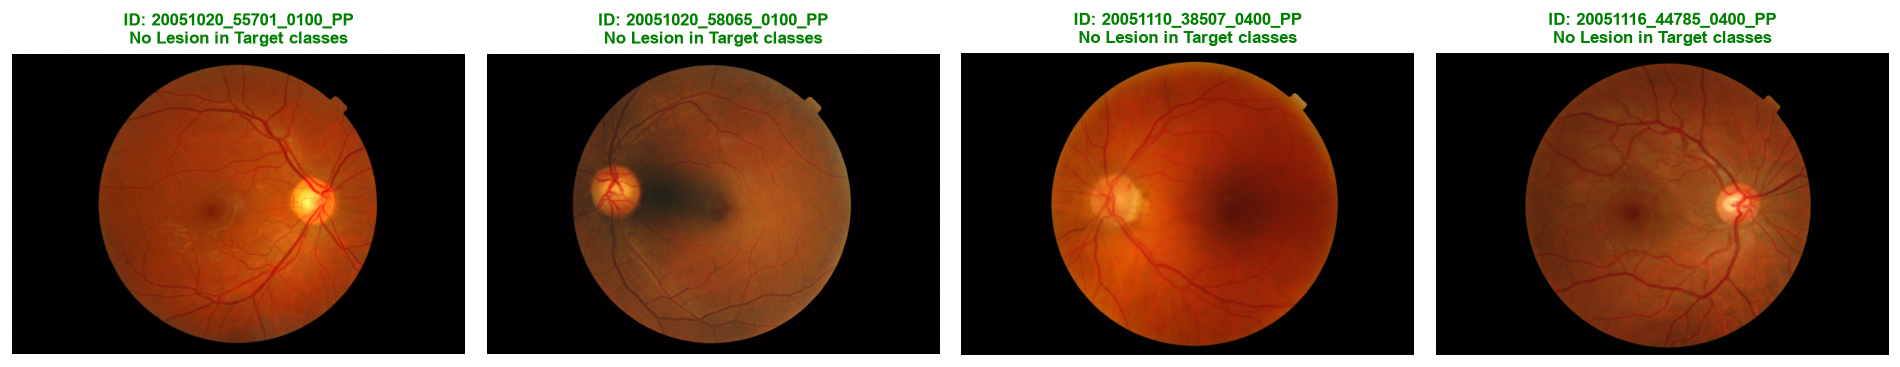

In [21]:
if len(normal_eyes) > 0:
    num_samples = min(4, len(normal_eyes))
    plt.figure(figsize=(16, 5))
    
    for i in range(num_samples):
        img_id = normal_eyes[i]
        img_search = glob.glob(os.path.join(col_images, f"{img_id}.*"))
        
        if img_search:
            img_path = img_search[0]
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            overlay = img.copy()
            
            # Apply Masks 
            detected_lesions = []
            for cls in disease_classes:
                m_path = os.path.join(col_masks, cls, f"{img_id}.png")
                if os.path.exists(m_path):
                    m = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)
                    if m is not None and cv2.countNonZero(m) > 0:
                        detected_lesions.append(cls)
                        color = class_colors.get(cls, (255, 255, 255))
                        overlay[m > 0] = color
            
            # Combined Original Image with Overlay
            alpha = 0.6
            blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
            
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(blended)
            
            is_clean = len(detected_lesions) == 0
            title_text = f"ID: {img_id}\n" + ("No Lesion in Target classes" if is_clean else f" found: {', '.join(detected_lesions)}")
            title_color = "green" if is_clean else "red"
            
            plt.title(title_text, fontsize=10, fontweight='bold', color=title_color)
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()
else:
    print("No Fundus without Lesion in Dataset")

- Save Meta Data of the Normal eyes : `normal_case.csv`

In [22]:
output_csv_path = os.path.join(Path.cwd()/'MetaData', 'normal_eyes.csv')

In [23]:
df_normal = pd.DataFrame({
    "Image_ID": normal_eyes
})

df_normal.to_csv(output_csv_path, index=True, encoding='utf-8')

---
## Step 6 — Visual Audit 

1. Find Image that's presented all target classes

In [48]:
hero_eyes = []
for img_id in tqdm(all_ids, desc="Finding Hero Images (All 5 masks)"):
    mask_count = 0
    for cls in target_class:
        m_path = os.path.join(col_masks, cls, f"{img_id}.png")
        # เช็คว่ามีไฟล์ Mask และไฟล์ Mask นั้นไม่ได้ว่างเปล่า (มีพิกเซลขาวอยู่)
        if os.path.exists(m_path):
            m = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)
            if m is not None and cv2.countNonZero(m) > 0:
                mask_count += 1
                
    # ถ้ามีครบ 5 อย่าง (OD, Macula, Exudates, Hemorrhages, Drusens)
    if mask_count == len(target_class):
        hero_eyes.append(img_id)
print(f"\nFound {len(hero_eyes)} Hero Images with ALL {len(target_class)} masks!")


Finding Hero Images (All 5 masks): 100%|██████████| 198/198 [00:11<00:00, 17.91it/s]


Found 37 Hero Images with ALL 5 masks!


In [50]:
if hero_eyes:
    best_img_id = hero_eyes[0]
    print(f"We will use '{best_img_id}' for our visual audit.")
else:
    print("No image contains all 5 masks perfectly. You might need to lower the threshold (e.g., mask_count >= 4).")

We will use '20051019_38557_0100_PP' for our visual audit.


2. Retrieve Original image

In [52]:
img_path = os.path.join(col_images, f"{best_img_id}.png")
if not os.path.exists(img_path): 
    img_path = os.path.join(col_images, f"{best_img_id}.tif")
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

3. Create overlay

In [53]:
overlay_img = img_rgb.copy()
mask_only_img = np.zeros_like(img_rgb)

In [55]:
for cls, color in class_colors.items():
    m_path = os.path.join(col_masks, cls, f"{best_img_id}.png")
    
    if os.path.exists(m_path):
        m = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)

        if m is not None and cv2.countNonZero(m) > 0:
            color_mask = np.zeros_like(img_rgb)
            color_mask[m > 0] = color 

            cv2.addWeighted(color_mask, 0.4, overlay_img, 1.0, 0, overlay_img)
            
            mask_only_img[m > 0] = color

4. Visualization the Sample

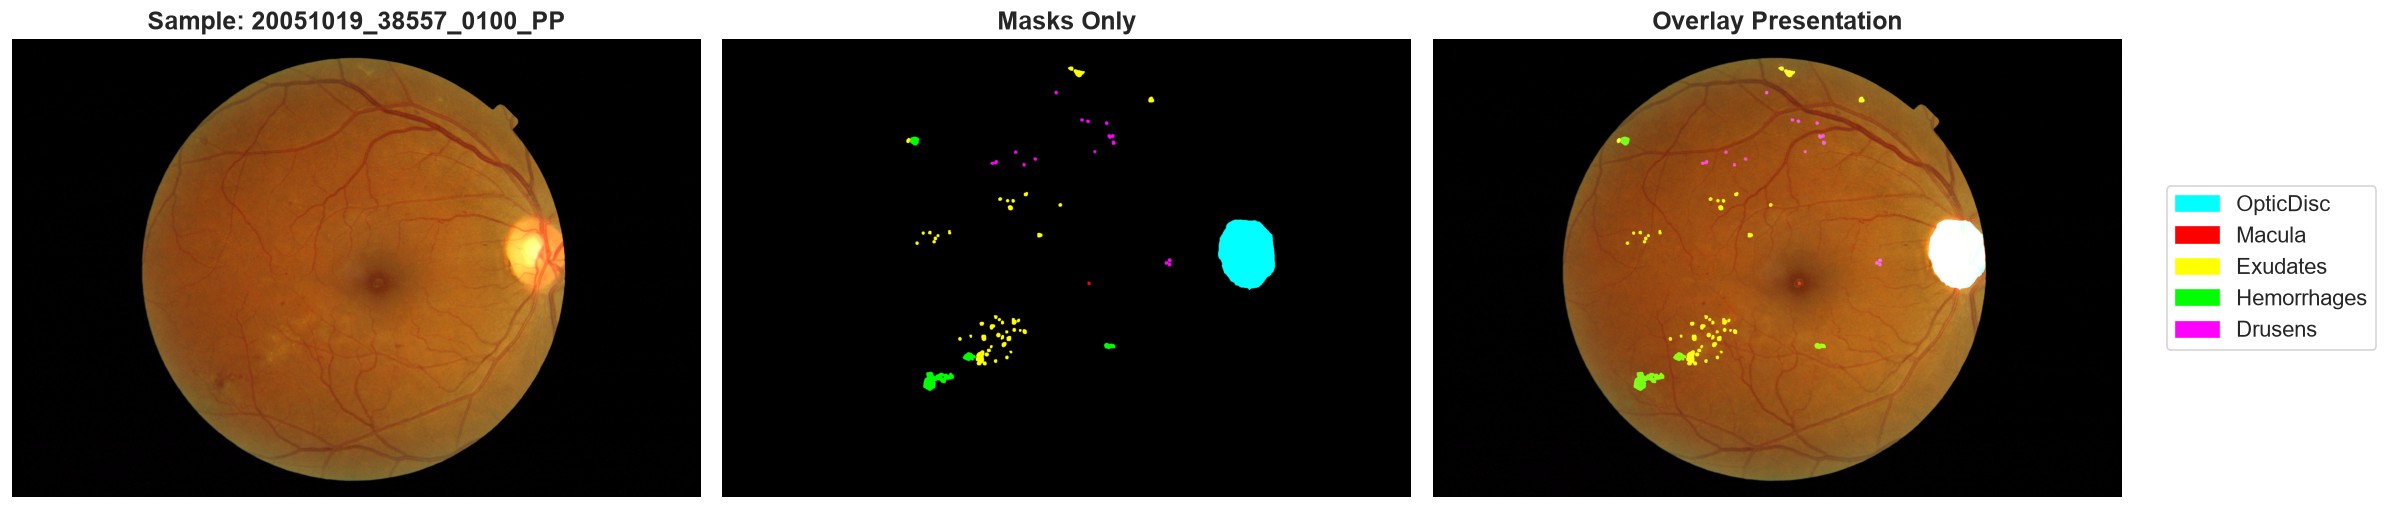

In [140]:
ig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(img_rgb)
axes[0].set_title(f"Sample: {best_img_id}", fontsize=15, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(mask_only_img)
axes[1].set_title("Masks Only", fontsize=15, fontweight='bold')
axes[1].axis('off')
axes[2].imshow(overlay_img)
axes[2].set_title("Overlay Presentation", fontsize=15, fontweight='bold')
axes[2].axis('off')
legend_patches = []
for cls, color in class_colors.items():
    norm_color = [c/255.0 for c in color]
    legend_patches.append(mpatches.Patch(color=norm_color, label=cls))
axes[2].legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=13)
plt.tight_layout()

fig_path = os.path.join(img_result, 'Five_classes_in_1_Sample.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()


---
## Step 7 — Image Resolution & Aspect Ratio
Check resolution consistency.

1. Resolution Value Counts

In [153]:
res_data = []
for img_path in glob.glob(os.path.join(col_images, "*")):
    with Image.open(img_path) as im:
        w, h = im.size
        res_data.append({"Width": w, "Height": h, "Aspect_Ratio": round(w / h, 3)})

df_res = pd.DataFrame(res_data)
df_res_sum = df_res[["Width", "Height"]].value_counts().reset_index(name="Count")
print(df_res_sum)

   Width  Height  Count
0   1440     960    104
1   2240    1488     53
2   2304    1536     41


- Export Result

In [154]:
Resolution_path = os.path.join(csv_result,'Resolution.csv')
df_res.to_csv(Resolution_path, index= False)
print(f'Saved result to: {Resolution_path}')

Resolution_sum_path = os.path.join(csv_result,'Resolution_Sum.csv')
df_res_sum.to_csv(Resolution_sum_path, index= False)
print(f'Saved result to: {Resolution_sum_path}')

Saved result to: d:\Backup\Senior-Project\Pre-Train\EDA_Results\statistic\Resolution.csv
Saved result to: d:\Backup\Senior-Project\Pre-Train\EDA_Results\statistic\Resolution_Sum.csv


2. Visualization

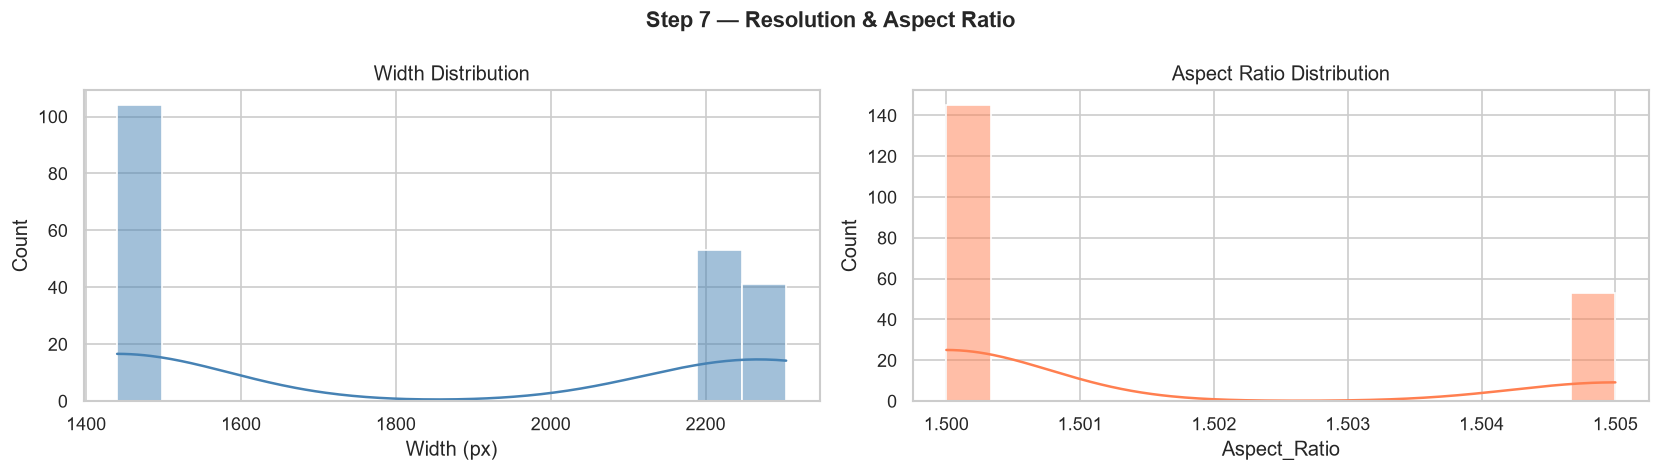

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_res["Width"], bins=15, ax=axes[0], color="steelblue", kde=True)
axes[0].set_title("Width Distribution"); axes[0].set_xlabel("Width (px)")
sns.histplot(df_res["Aspect_Ratio"], bins=15, ax=axes[1], color="coral",     kde=True)
axes[1].set_title("Aspect Ratio Distribution")
fig.suptitle("Step 7 — Resolution & Aspect Ratio", fontsize=13, fontweight="bold")
plt.tight_layout(); 

fig_path = os.path.join(img_result, 'Resolution_Aspect_Ratio.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

---
## Step 8 — Lesion Area Percentage (Log Scale)
What percentage of the image area does each lesion class account for? → Helps in planning the loss function.

1. Area Percentage Statistics

In [71]:
lesion_class = list(set(target_class)-{"OpticDisc","Macula"})
area_pct = []
for cls in lesion_class:
    cls_path = os.path.join(col_masks, cls)
    for fname in os.listdir(cls_path):
        mask          = np.array(Image.open(os.path.join(cls_path, fname)).convert("L"))
        lesion_pixels = int(np.sum(mask > 0))
        if lesion_pixels > 0:
            area_pct.append({"Class": cls, "Area_%": lesion_pixels / mask.size * 100})

df_area = pd.DataFrame(area_pct)

In [72]:
# Group by Class and calculate statistics (count, mean, std, min, 25%, 50%, 75%, max)df_area
stats_df = df_area.groupby("Class")["Area_%"].describe()

# Sorted by mean value (highest to lowest) for easy reading.
stats_df = stats_df.sort_values(by="mean", ascending=False)

# format to 6 decimal places
display(stats_df.style.format("{:.6f}"))


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Exudates,104.000000,0.311015,0.481720,0.001650,0.017939,0.109330,0.424265,2.653880
Hemorrhages,122.000000,0.190318,0.438156,0.003979,0.021703,0.068187,0.153537,3.345304
Drusens,90.000000,0.083709,0.203682,0.002387,0.007766,0.019230,0.065177,1.685981


- Export Result

In [156]:
Lesion_Area_path = os.path.join(csv_result,'Lesion_Area.csv')
stats_df.to_csv(Lesion_Area_path, index= True)
print(f'Saved result to: {Lesion_Area_path}')

Saved result to: d:\Backup\Senior-Project\Pre-Train\EDA_Results\statistic\Lesion_Area.csv


2. Visualization

C:\Users\natth\AppData\Local\Temp\ipykernel_39652\2480875646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_area, x="Area_%", y="Class",


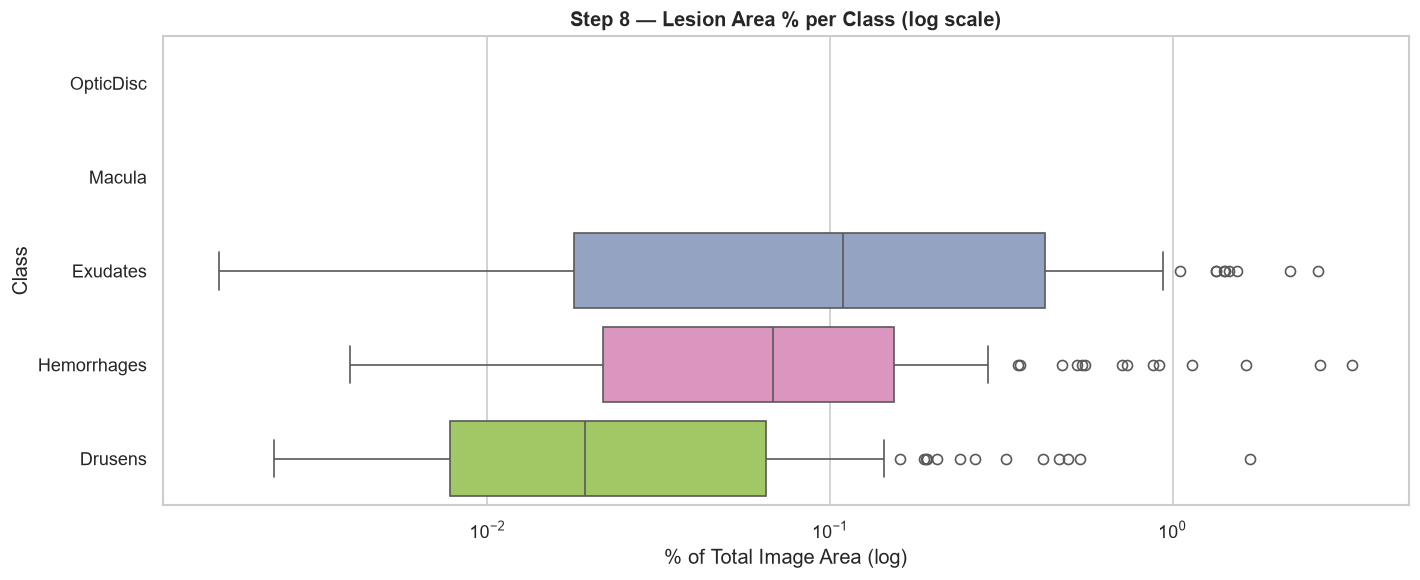

In [142]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_area, x="Area_%", y="Class",
            order=target_class, palette="Set2", ax=ax)
ax.set_xscale("log")
ax.set_title("Step 8 — Lesion Area % per Class (log scale)", fontweight="bold")
ax.set_xlabel("% of Total Image Area (log)")
plt.tight_layout(); 

fig_path = os.path.join(img_result, 'Lesion_Area.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

---
## Step 9 — Multi-label Co-occurrence Matrix
### 1. Number of Classes per Image


- Build binary presence matrix

In [77]:
all_img_ids  = [os.path.splitext(f)[0] for f in os.listdir(col_images)
                if f.lower().endswith((".png", ".tif", ".jpg"))]
occurrence   = []

for img_id in tqdm(all_img_ids, desc="Building presence matrix"):
    row = {"Image_ID": img_id}
    for cls in target_class:
        mask_path = os.path.join(col_masks, cls, f"{img_id}.png")
        if os.path.exists(mask_path):
            mask    = np.array(Image.open(mask_path).convert("L"))
            row[cls] = 1 if np.any(mask > 0) else 0
        else:
            row[cls] = 0
    occurrence.append(row)

df_occ = pd.DataFrame(occurrence)
df_occ["N_Classes"] = df_occ[target_class].sum(axis=1)

Building presence matrix: 100%|██████████| 198/198 [00:07<00:00, 26.35it/s]


- Label count distribution

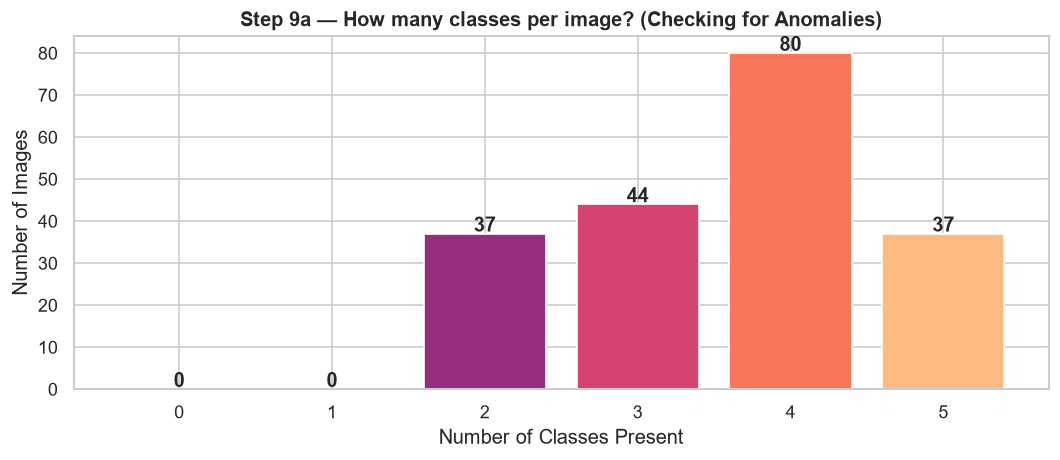

In [143]:
class_counts = df_occ["N_Classes"].value_counts()
all_possible_counts = pd.Series(0, index=range(len(target_class) + 1))

class_counts = class_counts.add(all_possible_counts, fill_value=0).astype(int)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(class_counts.index, class_counts.values,
              color=sns.color_palette("magma", len(class_counts)))

for bar, v in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5,
            str(v), ha="center", fontweight="bold")

ax.set_xticks(class_counts.index)
ax.set_xticklabels([f"{int(i)}" for i in class_counts.index])

ax.set_title("Step 9a — How many classes per image? (Checking for Anomalies)", fontweight="bold")
ax.set_xlabel("Number of Classes Present")
ax.set_ylabel("Number of Images")
plt.tight_layout()

fig_path = os.path.join(img_result, 'Classes_Per_Image.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

### 2. Class Correlation Heatmap

In [84]:
classes_to_check = ["OpticDisc", "Macula", "Exudates", "Hemorrhages", "Drusens"] 
df_occ["Present_Classes"] = df_occ[classes_to_check].apply(
    lambda row: ", ".join(row.index[row > 0]), axis=1
)
combo_counts = df_occ.groupby(["N_Classes", "Present_Classes"]).size().reset_index(name="Count")

In [86]:
for n in sorted(combo_counts["N_Classes"].unique()):
    print(f"\n[ Image with  {n} classes ]")
    
    # ดึงข้อมูลเฉพาะกลุ่มที่มี n คลาส และเรียงจากคอมโบที่เจอบ่อยสุดไปน้อยสุด
    subset = combo_counts[combo_counts["N_Classes"] == n].sort_values("Count", ascending=False)
    
    for _, row in subset.iterrows():
        print(f"{row['Count']:>3} images : {row['Present_Classes']}")


[ Image with  2 classes ]
 37 images : OpticDisc, Macula

[ Image with  3 classes ]
 20 images : OpticDisc, Macula, Hemorrhages
 12 images : OpticDisc, Macula, Drusens
 11 images : OpticDisc, Macula, Exudates
  1 images : OpticDisc, Exudates, Hemorrhages

[ Image with  4 classes ]
 39 images : OpticDisc, Macula, Exudates, Hemorrhages
 25 images : OpticDisc, Macula, Hemorrhages, Drusens
 16 images : OpticDisc, Macula, Exudates, Drusens

[ Image with  5 classes ]
 37 images : OpticDisc, Macula, Exudates, Hemorrhages, Drusens


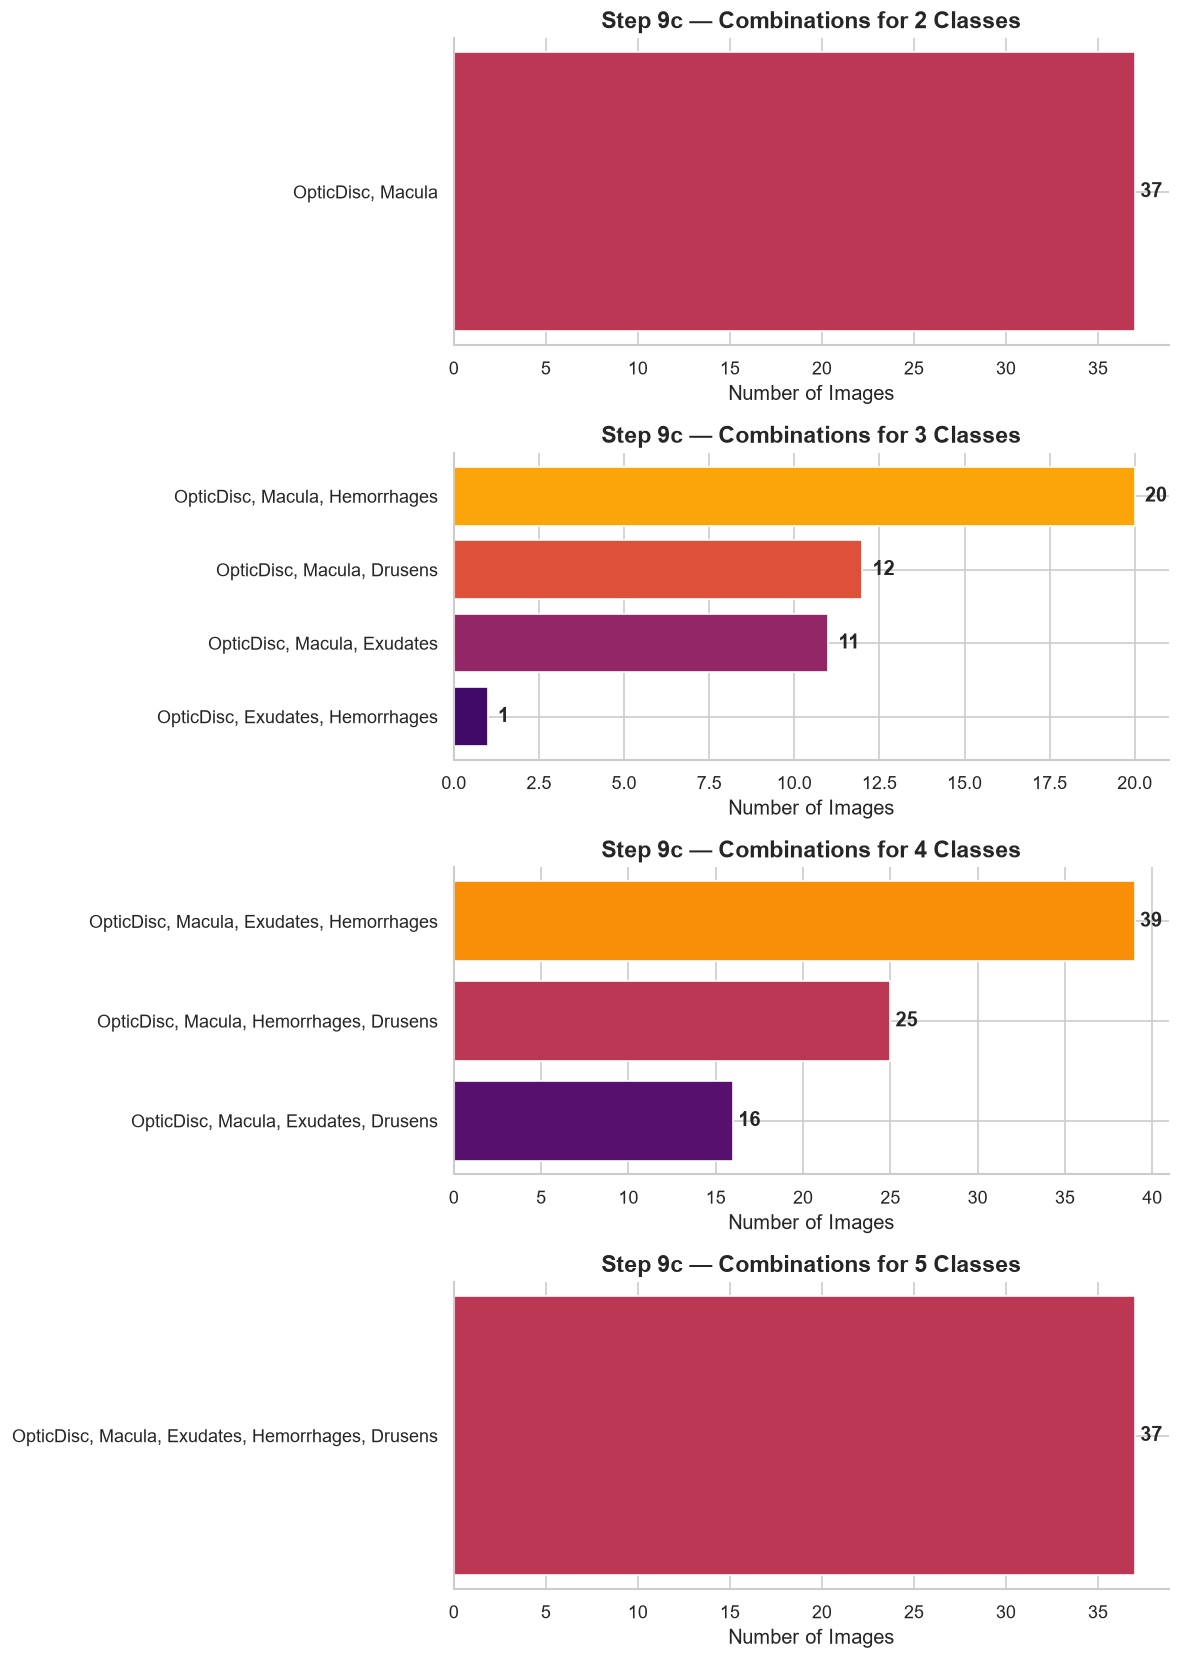

In [144]:
# Get unique N_Classes
unique_n = sorted(combo_counts["N_Classes"].unique())
num_plots = len(unique_n)

# Create vertical subplots
fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 3.5 * num_plots))

# Ensure axes is iterable for a single plot
if num_plots == 1:
    axes = [axes]

# Plot each class group
for ax, n in zip(axes, unique_n):
    
    # Filter and sort data (ascending for barh)
    subset = combo_counts[combo_counts["N_Classes"] == n].sort_values("Count", ascending=True)
    
    # Draw horizontal bar chart
    bars = ax.barh(subset["Present_Classes"], subset["Count"], 
                   color=sns.color_palette("inferno", len(subset)))
    
    # Add value labels to bars
    for bar in bars:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, 
                f"{int(bar.get_width())}", va='center', fontweight='bold')
    
    # Formatting
    ax.set_title(f"Step 9c — Combinations for {n} Classes", fontweight="bold", fontsize=14)
    ax.set_xlabel("Number of Images")
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

fig_path = os.path.join(img_result, 'Class_Core_Relation.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

- Corerelation heatmap

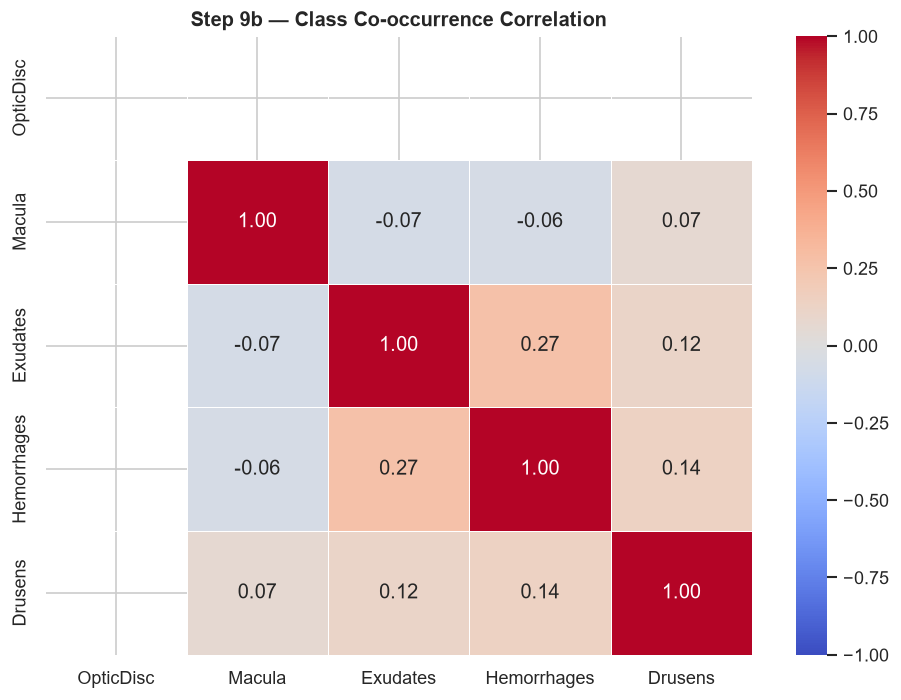

In [145]:
corr = df_occ[target_class].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title("Step 9b — Class Co-occurrence Correlation", fontweight="bold")
plt.tight_layout(); 

fig_path = os.path.join(img_result, 'Class_CO-occurrence_Heat_map.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

---
## Step 10 — Color Intensity Distribution
Analyze RGB variance to plan color normalization.

- Per-chanel Staatistic

In [98]:
mean_colors = []
for img_path in glob.glob(os.path.join(col_images, "*")):
    img = cv2.imread(img_path)                # BGR
    if img is None:
        continue
    mean_colors.append(img.reshape(-1, 3).mean(axis=0))   # [B, G, R]
df_color = pd.DataFrame(mean_colors, columns=["B", "G", "R"])

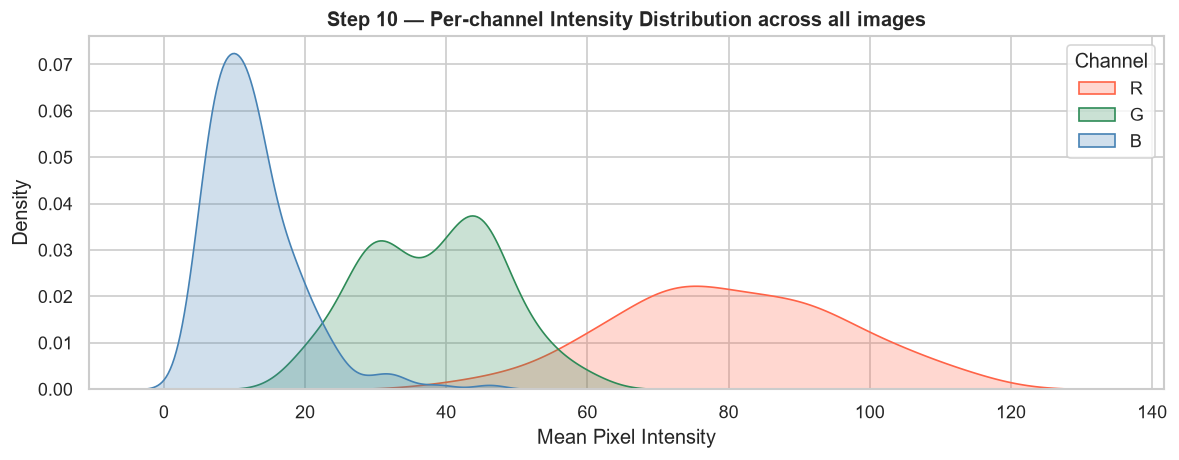

In [146]:
fig, ax = plt.subplots(figsize=(10, 4))
for ch, color in zip(["R", "G", "B"], ["tomato", "seagreen", "steelblue"]):
    sns.kdeplot(df_color[ch], ax=ax, color=color, label=ch, fill=True, alpha=0.25)
ax.set_title("Step 10 — Per-channel Intensity Distribution across all images", fontweight="bold")
ax.set_xlabel("Mean Pixel Intensity"); ax.set_ylabel("Density")
ax.legend(title="Channel")
plt.tight_layout(); 

fig_path = os.path.join(img_result, 'Per-channel_Intensity.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

In [102]:
display(df_color.describe().round(2))

,B,G,R
count,198.00,198.00,198.00
mean,12.62,38.15,80.07
std,6.50,9.68,16.16
min,3.04,18.04,38.38
25%,8.06,30.58,69.02
50%,11.42,39.15,79.65
75%,15.35,45.45,91.99
max,46.11,61.35,117.94


- Export Result

In [157]:
Intensity_path = os.path.join(csv_result,'Per_chanel_Intensity.csv')
df_color.to_csv(Intensity_path, index= True)
print(f'Saved result to: {Intensity_path}')

Saved result to: d:\Backup\Senior-Project\Pre-Train\EDA_Results\statistic\Per_chanel_Intensity.csv
